## Aplicação da extrategia de investimento do Basin



### Criterios:

 - Empresa com faturamento médio nos ultimos 3 anos maior que 300 milhoes para se enquadrar em grande empresa de acordo com o BNDES

### Criterios:
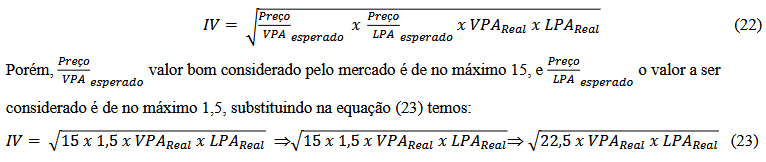

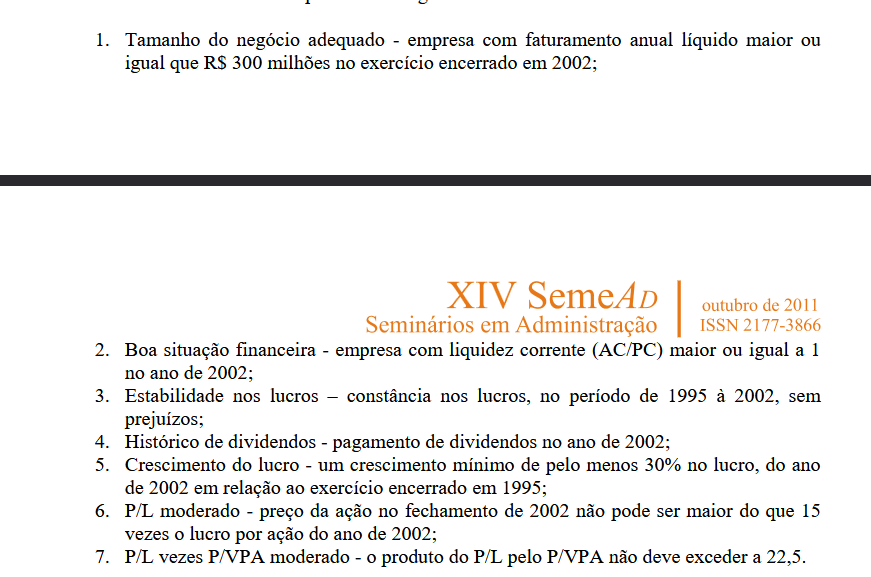

pego preco_medio/valor intriseco, o menor valor serão as que iremos investir

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import investpy as inv
from datetime import timedelta


In [36]:
# Definir equação do valor intrinseco de grahan
def grahan_equacao(vpa,lpa):
    preco_valor_patrimonial_esperado = 15
    preco_lucro_acao_esperado = 1.5
    return round((preco_valor_patrimonial_esperado*preco_lucro_acao_esperado*vpa*lpa)**(1/2),2)


In [37]:
# Para definir o valor do salario a ser utilizado será utilizado uma função que irá retornar o valor em questão
def investimento_ano(ano):
    SALARIOS = {2000:151,2001:180,2002:200, 2003:240, 2004:260, 2005:300,2006:350,2007:380,2008:415,2009:465,2010:510,2011:540,2012:622,2013:678,
            2014:724,2015:788,2016:880,2017:937,2018:954,2019:998,2020:1039,2021:1100,2022:1212,2023:1302,2024:1412}
    TAXA_INVEST = 0.075
    ano_atual = {}
    for anos in SALARIOS.keys():
        if anos == ano:
            ano_atual[ano]= SALARIOS[ano]
            valor_investido = ano_atual[ano]*TAXA_INVEST
    return round(valor_investido,2)

In [38]:
def correcao(ano,preco):
    INFLACAO_MEDIA = 0.0618
    ano_atual=pd.Timestamp.now().year
    periodo_correcao = ano_atual- ano
    correcao = (1+INFLACAO_MEDIA)**periodo_correcao
    preco_teto_corrigido = round((preco/correcao),2)
    return round(preco_teto_corrigido,2)

In [39]:
#Trazer empresas e ticker no brasil
bolsa_br = inv.stocks.get_stocks(country='Brazil')
bolsa_br

,country,name,full_name,isin,currency,symbol
0,brazil,ABC BRASIL PN,Banco ABC Brasil SA,BRABCBACNPR4,BRL,ABCB4
1,brazil,BRASILAGRO ON,BrasilAgro - Co ON NM,BRAGROACNOR7,BRL,AGRO3
2,brazil,RUMO ON NM,RUMO Logistica Operadora Multimodal SA,BRRAILACNOR9,BRL,RAIL3
3,brazil,ALPARGATAS ON,Alpargatas SA,BRALPAACNOR0,BRL,ALPA3
4,brazil,ALPARGATAS PN,Alpargatas SA,BRALPAACNPR7,BRL,ALPA4
...,...,...,...,...,...,...
744,brazil,Integral Brei Reit,Fdo Inv Imob Fof Integral Brei Reit,BRIBFFCTF007,BRL,IBFF11
745,brazil,Vbi Cri,Fi Imobiliario Vbi Cri,BRCVBICTF001,BRL,CVBI11
746,brazil,Hedge Realty,Hedge Realty Devl Fdo Inv Imob Etf,BRHRDFCTF000,BRL,HRDF11
747,brazil,Rb Cap,Rb Cap Desenvolvimento Res Iii Fii,BRRSPDCTF006,BRL,RSPD11


In [40]:
simbolos = bolsa_br["symbol"]

In [41]:
acoes_br = [acao+'.SA' for acao in simbolos if len(acao)<6]

In [42]:
filtro_receita =[]
for acao in acoes_br:
    empresa = yf.Ticker(acao)
    print(empresa)
    dados_financeiros = empresa.financials
    receita_media = dados_financeiros.loc['Total Revenue'].mean() if 'Total Revenue' in dados_financeiros.index else 0
    if receita_media >= 300000000:
        filtro_receita.append(acao)
print(filtro_receita)

yfinance.Ticker object <ABCB4.SA>
yfinance.Ticker object <AGRO3.SA>
yfinance.Ticker object <RAIL3.SA>
yfinance.Ticker object <ALPA3.SA>
yfinance.Ticker object <ALPA4.SA>
yfinance.Ticker object <ALSO3.SA>
yfinance.Ticker object <AMAR3.SA>
yfinance.Ticker object <ABEV3.SA>
yfinance.Ticker object <ADHM3.SA>
yfinance.Ticker object <ARZZ3.SA>
yfinance.Ticker object <BBAS3.SA>
yfinance.Ticker object <BBDC3.SA>
yfinance.Ticker object <BBDC4.SA>
yfinance.Ticker object <BBRK3.SA>
yfinance.Ticker object <BEEF3.SA>
yfinance.Ticker object <BPHA3.SA>
yfinance.Ticker object <BPAN4.SA>
yfinance.Ticker object <BRAP3.SA>
yfinance.Ticker object <BRAP4.SA>
yfinance.Ticker object <BRFS3.SA>
yfinance.Ticker object <APER3.SA>
yfinance.Ticker object <BRKM3.SA>
yfinance.Ticker object <BRKM5.SA>
yfinance.Ticker object <BRML3.SA>
yfinance.Ticker object <BRPR3.SA>
yfinance.Ticker object <BRSR6.SA>
yfinance.Ticker object <OIBR3.SA>
yfinance.Ticker object <OIBR4.SA>
yfinance.Ticker object <BTOW3.SA>
yfinance.Ticke

In [43]:
len(filtro_receita)

233

In [44]:
#Empresa com liquidez maior que 1 nos ultimos 3 anos

linha = 0
lista_filtro_liquidez= []
for acao in filtro_receita:
    empresa= yf.Ticker(acao)
    balanco = empresa.balance_sheet
    ativos_circulante = balanco.loc['Current Assets'].mean() if 'Current Assets' in balanco.index else 0
    passivos_circulante = balanco.loc['Current Liabilities'].mean() if 'Current Liabilities' in balanco.index else 0
    if ativos_circulante == 0 and passivos_circulante == 0:
        liquidez_corrente = 0
    elif ativos_circulante == 0:
        liquidez_corrente = 0
    else:
        liquidez_corrente = ativos_circulante/passivos_circulante 
    if liquidez_corrente >= 1:
        lista_filtro_liquidez.append(acao)

In [45]:
len(lista_filtro_liquidez)

166

In [46]:
#Empresa com lucros insonstantes, será q que divulgou lucros =< 0 nos ultimos 3 anos devido a ser isso o tamnaho da minha base de dados
filtro_lucro_inconstante = []
for acao in lista_filtro_liquidez:
    empresa = yf.Ticker(acao)
    dados_financeiros = empresa.financials
    lucro = dados_financeiros.loc['Net Income'][:3]
    linha = 0
    verificao = []
    while linha < len(lucro):
        if lucro[linha] <= 0:
            verificao.append('inconstante')
        else:
            verificao.append('constante')
        linha+=1
    if 'inconstante' not in verificao:
        filtro_lucro_inconstante.append(acao)

C:\Users\edens\AppData\Local\Temp\ipykernel_20524\949850220.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if lucro[linha] <= 0:
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\949850220.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if lucro[linha] <= 0:
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\949850220.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if lucro[linha] <= 0:
C:\Users\edens\AppData\Local\Te

In [47]:
print(len(filtro_lucro_inconstante))

126


In [48]:
PERIODO = 3
tempo_atual = pd.Timestamp.now().year
tempo_inicio = tempo_atual-PERIODO

anos_para_calculo= []
for variacao in range (1,4):
    print(variacao)
    diferenca = PERIODO - variacao
    print(diferenca)
    tempo_calculado = tempo_atual - diferenca
    print(tempo_calculado)
    anos_para_calculo.append(tempo_calculado)
anos_para_calculo
print(tempo_inicio)

1
2
2023
2
1
2024
3
0
2025
2022


In [49]:
# Preciso calcular o VPA
df_acoes = pd.DataFrame(filtro_lucro_inconstante,columns= ['Ticker'])
df_acoes


,Ticker
0,AGRO3.SA
1,BEEF3.SA
2,B3SA3.SA
3,CCRO3.SA
4,CGAS5.SA
...,...
121,ENMT4.SA
122,RSUL4.SA
123,VAMO3.SA
124,VIVA3.SA


In [50]:
PERIODO = 3
tempo_final = '2024-12-31'
tempo_final=pd.to_datetime(tempo_final)

tempo_inicial = tempo_final- timedelta(days= 365*PERIODO)
print(tempo_final,tempo_inicial)

2024-12-31 00:00:00 2022-01-01 00:00:00


In [51]:
contador = 0
while contador < len(df_acoes):
    empresa = yf.Ticker(df_acoes.loc[contador, "Ticker"])
    informacao = empresa.info
    dados_financeiros = empresa.financials
    preco = empresa.history(start = tempo_inicial, end=tempo_final, period= '1y')
    preco_medio = preco['Close'].mean()
    lucro = dados_financeiros.loc['Net Income'].mean() if 'Net Income' in dados_financeiros.index else 0
    valor_patrimonial = informacao.get('bookValue')
    acoes= informacao.get('sharesOutstanding')
    lucro_acao = lucro/acoes if lucro and acoes != None else 0
    df_acoes.loc[contador, "Lucro_médio/Acao"]=  lucro_acao
    df_acoes.loc[contador, "Valo_patrimonial/Acao"]= valor_patrimonial
    df_acoes.loc[contador, "Preco_medio"]= preco_medio
    contador += 1

In [52]:
df_acoes.fillna(0,inplace=True)
df_acoes

,Ticker,Lucro_médio/Acao,Valo_patrimonial/Acao,Preco_medio
0,AGRO3.SA,3.345737,22.112,22.516133
1,BEEF3.SA,1.006907,1.265,9.321200
2,B3SA3.SA,0.842901,3.489,11.725427
3,CCRO3.SA,0.967884,6.770,12.268342
4,CGAS5.SA,62.215618,7.501,106.226868
...,...,...,...,...
121,ENMT4.SA,7.431838,18.124,69.316097
122,RSUL4.SA,20.450702,36.352,65.754346
123,VAMO3.SA,0.426033,4.767,9.851795
124,VIVA3.SA,1.249943,9.712,24.915864


In [53]:
df_acoes_nulos_filtrado = df_acoes[df_acoes['Lucro_médio/Acao']>0].reset_index(drop=True)
len(df_acoes_nulos_filtrado)

126

In [54]:
df_acoes_nulos_filtrado['Preco/Valor_Patrimonial']= df_acoes_nulos_filtrado['Preco_medio']/df_acoes_nulos_filtrado["Valo_patrimonial/Acao"]
df_acoes_nulos_filtrado['preco/lucro']= df_acoes_nulos_filtrado['Preco_medio']/df_acoes_nulos_filtrado['Lucro_médio/Acao']

In [55]:
df_acoes_nulos_filtrado["Valor_Intrinseco"]= grahan_equacao(df_acoes_nulos_filtrado['preco/lucro'],df_acoes_nulos_filtrado["Preco/Valor_Patrimonial"])

In [56]:
df_acoes_nulos_filtrado['Razao_preco_valor_intrinsico'] = df_acoes_nulos_filtrado['Preco_medio']/df_acoes_nulos_filtrado['Valor_Intrinseco']
df_acoes_nulos_filtrado

,Ticker,Lucro_médio/Acao,Valo_patrimonial/Acao,Preco_medio,Preco/Valor_Patrimonial,preco/lucro,Valor_Intrinseco,Razao_preco_valor_intrinsico
0,AGRO3.SA,3.345737,22.112,22.516133,1.018277,6.729798,12.42,1.812893
1,BEEF3.SA,1.006907,1.265,9.321200,7.368538,9.257262,39.18,0.237907
2,B3SA3.SA,0.842901,3.489,11.725427,3.360684,13.910798,32.43,0.361561
3,CCRO3.SA,0.967884,6.770,12.268342,1.812163,12.675422,22.73,0.539742
4,CGAS5.SA,62.215618,7.501,106.226868,14.161694,1.707399,23.32,4.555183
...,...,...,...,...,...,...,...,...
121,ENMT4.SA,7.431838,18.124,69.316097,3.824547,9.326912,28.33,2.446738
122,RSUL4.SA,20.450702,36.352,65.754346,1.808823,3.215261,11.44,5.747758
123,VAMO3.SA,0.426033,4.767,9.851795,2.066666,23.124508,32.79,0.300451
124,VIVA3.SA,1.249943,9.712,24.915864,2.565472,19.933602,33.92,0.734548


In [57]:
df_acoes_nulos_filtrado['empresa']= df_acoes_nulos_filtrado['Ticker'].str[:4]
df_carteira_grahan_sem_cemig=df_acoes_nulos_filtrado[df_acoes_nulos_filtrado['Ticker']!= 'CMIG4.SA']
df_carteira_grahan_sem_tupy=df_carteira_grahan_sem_cemig[df_carteira_grahan_sem_cemig['Ticker']!= 'TUPY3.SA']
df_carteira_grahan_ordenada = df_carteira_grahan_sem_tupy.sort_values('Razao_preco_valor_intrinsico', ascending=True)
df_carteira_grahan = df_carteira_grahan_ordenada.drop_duplicates('empresa',keep='first').reset_index(drop=True).head(10)

# Devido uma inconsistencia encontrada nos dados da cmig4 devido aos precos dela, foi decidido realizar a sua remoção e pegar outro
#ativo da lista para fazer os teste

In [58]:
CARTEIRA_GRAHAN= df_carteira_grahan[['Ticker','Valor_Intrinseco']]
CARTEIRA_GRAHAN

,Ticker,Valor_Intrinseco
0,STBP3.SA,56.34
1,KLBN4.SA,18.40
2,WHRL3.SA,20.05
3,REDE3.SA,22.38
4,BEEF3.SA,39.18
5,CEAB3.SA,23.26
6,VAMO3.SA,32.79
7,POMO4.SA,14.35
8,RADL3.SA,77.15
9,TECN3.SA,9.60


In [59]:
SALARIOS = {2000:151,2001:180,2002:200, 2003:240, 2004:260, 2005:300,2006:350,2007:380,2008:415,2009:465,2010:510,2011:540,2012:622,2013:678,
            2014:724,2015:788,2016:880,2017:937,2018:954,2019:998,2020:1039,2021:1100,2022:1212,2023:1302,2024:1412}

In [60]:
CARTEIRA_GRAHAN.columns

Index(['Ticker', 'Valor_Intrinseco'], dtype='object')

In [61]:
for ano in SALARIOS.keys():
    for acao in CARTEIRA_GRAHAN['Ticker']:
        valor_intrinseco = CARTEIRA_GRAHAN.loc[CARTEIRA_GRAHAN['Ticker']== acao,"Valor_Intrinseco"]
        CARTEIRA_GRAHAN.loc[CARTEIRA_GRAHAN['Ticker']== acao,ano] = correcao(ano,valor_intrinseco)

C:\Users\edens\AppData\Local\Temp\ipykernel_20524\3913455388.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CARTEIRA_GRAHAN.loc[CARTEIRA_GRAHAN['Ticker']== acao,ano] = correcao(ano,valor_intrinseco)
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\3913455388.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CARTEIRA_GRAHAN.loc[CARTEIRA_GRAHAN['Ticker']== acao,ano] = correcao(ano,valor_intrinseco)
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\3913455388.py:4: SettingWithCopyWarning: 
A value is t

In [62]:
CARTEIRA_GRAHAN

,Ticker,Valor_Intrinseco,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,STBP3.SA,56.34,12.58,13.36,14.19,15.06,15.99,16.98,18.03,19.14,...,30.93,32.84,34.87,37.03,39.32,41.74,44.32,47.06,49.97,53.06
1,KLBN4.SA,18.40,4.11,4.36,4.63,4.92,5.22,5.55,5.89,6.25,...,10.10,10.73,11.39,12.09,12.84,13.63,14.48,15.37,16.32,17.33
2,WHRL3.SA,20.05,4.48,4.75,5.05,5.36,5.69,6.04,6.42,6.81,...,11.01,11.69,12.41,13.18,13.99,14.86,15.77,16.75,17.78,18.88
3,REDE3.SA,22.38,5.00,5.31,5.63,5.98,6.35,6.75,7.16,7.60,...,12.29,13.05,13.85,14.71,15.62,16.58,17.61,18.70,19.85,21.08
4,BEEF3.SA,39.18,8.75,9.29,9.86,10.47,11.12,11.81,12.54,13.31,...,21.51,22.84,24.25,25.75,27.34,29.03,30.82,32.73,34.75,36.90
5,CEAB3.SA,23.26,5.19,5.52,5.86,6.22,6.60,7.01,7.44,7.90,...,12.77,13.56,14.40,15.29,16.23,17.23,18.30,19.43,20.63,21.91
6,VAMO3.SA,32.79,7.32,7.78,8.26,8.77,9.31,9.88,10.49,11.14,...,18.00,19.11,20.30,21.55,22.88,24.30,25.80,27.39,29.08,30.88
7,POMO4.SA,14.35,3.20,3.40,3.61,3.84,4.07,4.33,4.59,4.88,...,7.88,8.37,8.88,9.43,10.01,10.63,11.29,11.99,12.73,13.51
8,RADL3.SA,77.15,17.23,18.29,19.42,20.63,21.90,23.25,24.69,26.22,...,42.36,44.97,47.75,50.70,53.84,57.16,60.70,64.45,68.43,72.66
9,TECN3.SA,9.60,2.14,2.28,2.42,2.57,2.73,2.89,3.07,3.26,...,5.27,5.60,5.94,6.31,6.70,7.11,7.55,8.02,8.52,9.04


In [63]:
# Tempo do backtest
ano_inicio = '2000-01-01'
ano_inicio = pd.to_datetime(ano_inicio)

In [64]:
preco={}
for acao in CARTEIRA_GRAHAN['Ticker']:
    empresa= yf.Ticker(acao)
    precos = empresa.history(start=ano_inicio,end=tempo_final, period='1mo')
    preco_fechamento = precos['Close']
    preco[acao] = preco_fechamento.resample('M').last()
bolsa_graham = pd.DataFrame(preco).reset_index()
bolsa_graham




C:\Users\edens\AppData\Local\Temp\ipykernel_20524\1015240220.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco[acao] = preco_fechamento.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\1015240220.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco[acao] = preco_fechamento.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\1015240220.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco[acao] = preco_fechamento.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\1015240220.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  preco[acao] = preco_fechamento.resample('M').last()
C:\Users\edens\AppData\Local\Temp\ipykernel_20524\1015240220.py:6: FutureWarning: 'M' is deprecated and will be removed 

,Date,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
0,2000-01-31 00:00:00-02:00,NaN,NaN,0.128088,0.360784,NaN,NaN,NaN,0.148647,0.004700,NaN
1,2000-02-29 00:00:00-03:00,NaN,NaN,0.128088,0.403921,NaN,NaN,NaN,0.212352,0.005372,NaN
2,2000-03-31 00:00:00-03:00,NaN,NaN,0.126147,0.478431,NaN,NaN,NaN,0.178225,0.005372,NaN
3,2000-04-30 00:00:00-03:00,NaN,NaN,0.116443,0.396862,NaN,NaN,NaN,0.197185,0.005372,NaN
4,2000-05-31 00:00:00-03:00,NaN,NaN,0.116443,0.392156,NaN,NaN,NaN,0.214628,0.005372,NaN
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31 00:00:00-03:00,11.157625,4.247353,3.921557,6.628304,7.49,9.734533,7.247877,7.024553,27.341482,5.196373
296,2024-09-30 00:00:00-03:00,12.668196,4.091486,4.409856,6.580959,6.34,10.050403,6.303746,7.597985,25.287897,4.689177
297,2024-10-31 00:00:00-03:00,12.585632,4.062262,3.996732,6.401048,5.80,12.472071,5.998572,8.085403,24.268383,5.215512
298,2024-11-30 00:00:00-03:00,12.774965,4.359582,3.996732,6.339721,5.85,10.117405,5.521738,8.331401,23.969267,5.646151


In [65]:
CARTEIRA_GRAHAN[2024]

0    53.06
1    17.33
2    18.88
3    21.08
4    36.90
5    21.91
6    30.88
7    13.51
8    72.66
9     9.04
Name: 2024, dtype: float64

In [66]:
bolsa_graham.loc[299]

Date        2024-12-31 00:00:00-03:00
STBP3.SA                        13.13
KLBN4.SA                         4.59
WHRL3.SA                         3.84
REDE3.SA                     6.079185
BEEF3.SA                         5.09
CEAB3.SA                     7.705309
VAMO3.SA                         4.75
POMO4.SA                     7.157827
RADL3.SA                         22.0
TECN3.SA                     5.272931
Name: 299, dtype: object

In [67]:
#Desconsiderando splits que ocorreram nos periodos
contador = 0
saldo=0
carteira_contabil_graham = 0
valor_investido_graham = 0
compras_graham = {acao:0 for acao in CARTEIRA_GRAHAN['Ticker']}
while contador < len(bolsa_graham):
    data= bolsa_graham.loc[contador,'Date'].year
    saldo += investimento_ano(data)
    valor_investido_graham += investimento_ano(data)
    while True:
        compra_acao = False
        for acao in CARTEIRA_GRAHAN['Ticker']:
           preco = bolsa_graham.loc[contador,acao]
           preco_teto = CARTEIRA_GRAHAN.loc[CARTEIRA_GRAHAN['Ticker']==acao,data].values[0]
           if preco >0 and preco< preco_teto and saldo> preco:
               compras_graham[acao] +=1
               saldo -= preco
               carteira_contabil_graham += preco
               compra_acao = True
        if not compra_acao:
            break
    contador +=1
    
print(compras_graham)
print(carteira_contabil_graham)
print(valor_investido_graham)

{'STBP3.SA': 639, 'KLBN4.SA': 623, 'WHRL3.SA': 2450, 'REDE3.SA': 2353, 'BEEF3.SA': 455, 'CEAB3.SA': 70, 'VAMO3.SA': 47, 'POMO4.SA': 2275, 'RADL3.SA': 2425, 'TECN3.SA': 195}
14972.697259357199
14973.120000000006


In [68]:
file = pd.ExcelWriter('Arquivo_Graham.xlsx', engine='openpyxl')
bolsa_graham_salv= bolsa_graham.fillna(0)
bolsa_graham_salv['Date'] = bolsa_graham['Date'].dt.strftime('%Y-%m-%d')
bolsa_graham_salv.to_excel(file, sheet_name='Bolsa Graham', index=False)
dicionario_inf = {
    'Nome':['carteira_contabil_graham','valor_investido_graham'],
    'Valor':[carteira_contabil_graham,valor_investido_graham]}
df_valor = pd.DataFrame(dicionario_inf)
df_valor.to_excel(file, sheet_name='valor_investido_vs_investimento', index=False)
compra_feita = {
    'Acao' : [acao for acao in compras_graham.keys()],
    'Qtd_comprada': [valor for valor in compras_graham.values()]}
compra_df = pd.DataFrame(compra_feita)
compra_df.to_excel(file, sheet_name='Compras', index=False)
file.close()